# Performance Comparison: Scalar vs Vectorized Implementations


This notebook benchmarks the performance of the vectorized geopack functions:


- Coordinate transformations (GSM/GSE, GEO/MAG, etc.)

- Field-vector conversions (bspcar, bcarsp)

- Tsyganenko external field models (T89/T96/T01/T04)

- Internal field models (Dipole, IGRF)

- Cost decomposition: function-call overhead vs per-point cost (Section 3c)

- (Optional) Field line tracing (only if a vectorized tracer exists in your geopack namespace)


Notes

---

- This notebook is about **performance** (timing/speed), not numerical accuracy.

- Some models (notably **T01/T04**) have a recommended validity domain (sunward of x = -15 Re).

  We therefore **sample model points per-model** to avoid warnings and out-of-domain calls in benchmarks.

- Times depend strongly on CPU, BLAS/NumPy build, and Python version. Treat results as indicative.

In [1]:
# Imports / environment
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopack
import time
import os
import gc
from datetime import datetime

# psutil is optional (used only for memory reporting)
try:
    import psutil
    _HAS_PSUTIL = True
except Exception:
    psutil = None
    _HAS_PSUTIL = False

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

# Initialize geopack
ut = datetime(2020, 1, 1, 12, 0, 0).timestamp()
ps = geopack.recalc(ut)

print("Environment")
print("=" * 60)
print("datetime(UT):", datetime.fromtimestamp(ut))
print("ps (tilt):", ps)
if _HAS_PSUTIL:
    vm = psutil.virtual_memory()
    print(f"CPU cores: {psutil.cpu_count(logical=True)}  RAM: {vm.total/1e9:.1f} GB")
else:
    print("psutil: not available (memory section will be limited)")
print("numpy:", np.__version__)


Load IGRF coefficients ...


Environment
datetime(UT): 2020-01-01 12:00:00
ps (tilt): -0.5451500462386779
CPU cores: 16  RAM: 16.6 GB
numpy: 2.5.1


## 1. Setup and Methodology <a name="setup"></a>


We measure:

- **Execution time** for different array sizes

- **Speedup factor** = scalar_time / vector_time

- **Processing rate** (points/second)


Benchmark policy:

- Use `time.perf_counter()` (high-resolution timer)

- Use a small warmup call for vector functions

- For large n, scalar timing is capped at `max_scalar_points` and extrapolated

  (reported as "extrapolated" in the result dict)

In [2]:
# Test sizes (kept moderate for interactive execution)
test_sizes = [1, 10, 50, 100, 500, 1000, 5000, 10000]

# Scalar cap for timing (extrapolate above this)
MAX_SCALAR_POINTS = 1000

# Repeats (take min)
N_REPEATS = 3

# RNG seed
SEED = 42

def _now():
    return time.perf_counter()

def _as_f64(a):
    return np.asarray(a, dtype=np.float64)

def sample_xyz(n_points, xlim, ylim, zlim, seed=SEED):
    """Sample Cartesian points with float64 dtype."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(xlim[0], xlim[1], n_points)
    y = rng.uniform(ylim[0], ylim[1], n_points)
    z = rng.uniform(zlim[0], zlim[1], n_points)
    return _as_f64(x), _as_f64(y), _as_f64(z)

def sample_spherical_inputs(n_points, seed=SEED):
    """Sample (theta, phi, br, bt, bp) for bspcar-style calls."""
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0.0, np.pi, n_points)
    phi   = rng.uniform(0.0, 2*np.pi, n_points)
    br = rng.normal(0.0, 1.0, n_points)
    bt = rng.normal(0.0, 1.0, n_points)
    bp = rng.normal(0.0, 1.0, n_points)
    return (_as_f64(theta), _as_f64(phi), _as_f64(br), _as_f64(bt), _as_f64(bp))

def measure_performance(
    scalar_func,
    vector_func,
    n_points,
    func_type,
    *,
    params=None,
    model_name=None,
    direction=1,
    n_repeats=N_REPEATS,
    max_scalar_points=MAX_SCALAR_POINTS,
    seed=SEED,
):
    """
    Measure scalar vs vector performance.

    func_type:
      - "coord" : signature (x,y,z,dir)
      - "sphcar": signature (x,y,z,dir) but expects cart->sph for dir=-1 (recommended here)
      - "bspcar": signature (theta,phi,br,bt,bp)
      - "bcarsp": signature (x,y,z,bx,by,bz)
      - "model" : signature (params, ps, x,y,z)  (T89 uses int iopt as params)
      - "igrf"  : signature (x,y,z)  (no ps)
      - "dip"   : signature (x,y,z)  (no ps)
    """
    # Per-type input generation
    if func_type in ("coord", "sphcar"):
        # Cartesian-like inputs for transforms; sphcar is safest in car->sph mode (dir=-1)
        x, y, z = sample_xyz(n_points, (-15, 15), (-15, 15), (-15, 15), seed=seed)
    elif func_type == "model":
        # Model-domain-aware sampling:
        # - T01/T04: avoid x < -15 (recommended validity)
        # - Others: allow wider tail sampling
        if model_name is not None and model_name.upper() in ("T01", "T04"):
            x, y, z = sample_xyz(n_points, (-15.0, 12.0), (-15, 15), (-15, 15), seed=seed)
        else:
            x, y, z = sample_xyz(n_points, (-25.0, 12.0), (-15, 15), (-15, 15), seed=seed)
    elif func_type in ("igrf", "dip"):
        # Keep IGRF stable: near-Earth domain (typical usage)
        x, y, z = sample_xyz(n_points, (-10.0, 10.0), (-10.0, 10.0), (-10.0, 10.0), seed=seed)
    elif func_type == "bspcar":
        theta, phi, br, bt, bp = sample_spherical_inputs(n_points, seed=seed)
    elif func_type == "bcarsp":
        x, y, z = sample_xyz(n_points, (-15, 15), (-15, 15), (-15, 15), seed=seed)
        bx = 0.1 * x
        by = 0.1 * y
        bz = 0.1 * z
    else:
        raise ValueError(f"Unknown func_type: {func_type}")

    # Warmup (vector only)
    try:
        if func_type == "coord":
            vector_func(x[:5], y[:5], z[:5], direction)
        elif func_type == "sphcar":
            vector_func(x[:5], y[:5], z[:5], direction)
        elif func_type == "model":
            vector_func(params, ps, x[:5], y[:5], z[:5])
        elif func_type in ("igrf", "dip"):
            vector_func(x[:5], y[:5], z[:5])
        elif func_type == "bspcar":
            vector_func(theta[:5], phi[:5], br[:5], bt[:5], bp[:5])
        elif func_type == "bcarsp":
            vector_func(x[:5], y[:5], z[:5], bx[:5], by[:5], bz[:5])
    except Exception:
        # Warmup is best-effort; ignore if function doesn't like short inputs in some envs
        pass

    # Scalar timing (cap and extrapolate)
    n_scalar = min(n_points, max_scalar_points)
    scalar_times = []
    for _ in range(n_repeats):
        t0 = _now()
        if func_type == "coord":
            for i in range(n_scalar):
                scalar_func(float(x[i]), float(y[i]), float(z[i]), int(direction))
        elif func_type == "sphcar":
            for i in range(n_scalar):
                scalar_func(float(x[i]), float(y[i]), float(z[i]), int(direction))
        elif func_type == "model":
            for i in range(n_scalar):
                scalar_func(params, ps, float(x[i]), float(y[i]), float(z[i]))
        elif func_type in ("igrf", "dip"):
            for i in range(n_scalar):
                scalar_func(float(x[i]), float(y[i]), float(z[i]))
        elif func_type == "bspcar":
            for i in range(n_scalar):
                scalar_func(float(theta[i]), float(phi[i]), float(br[i]), float(bt[i]), float(bp[i]))
        elif func_type == "bcarsp":
            for i in range(n_scalar):
                scalar_func(float(x[i]), float(y[i]), float(z[i]), float(bx[i]), float(by[i]), float(bz[i]))
        scalar_times.append(_now() - t0)

    scalar_time_meas = float(np.min(scalar_times))
    extrapolated = n_scalar < n_points
    scalar_time = scalar_time_meas * (n_points / max(n_scalar, 1)) if extrapolated else scalar_time_meas

    # Vector timing (full n_points)
    vector_times = []
    for _ in range(n_repeats):
        t0 = _now()
        if func_type == "coord":
            vector_func(x, y, z, direction)
        elif func_type == "sphcar":
            vector_func(x, y, z, direction)
        elif func_type == "model":
            vector_func(params, ps, x, y, z)
        elif func_type in ("igrf", "dip"):
            vector_func(x, y, z)
        elif func_type == "bspcar":
            vector_func(theta, phi, br, bt, bp)
        elif func_type == "bcarsp":
            vector_func(x, y, z, bx, by, bz)
        vector_times.append(_now() - t0)

    vector_time = float(np.min(vector_times))

    # Metrics
    speedup = scalar_time / max(vector_time, 1e-15)
    scalar_rate = n_points / max(scalar_time, 1e-15)
    vector_rate = n_points / max(vector_time, 1e-15)

    return {
        "n_points": int(n_points),
        "scalar_time_s": float(scalar_time),
        "vector_time_s": float(vector_time),
        "speedup_x": float(speedup),
        "scalar_rate_pts_s": float(scalar_rate),
        "vector_rate_pts_s": float(vector_rate),
        "scalar_extrapolated": bool(extrapolated),
        "n_scalar_measured": int(n_scalar),
    }

print("Benchmark setup complete.")
print(f"test_sizes: {test_sizes}")
print(f"MAX_SCALAR_POINTS: {MAX_SCALAR_POINTS}, N_REPEATS: {N_REPEATS}")


Benchmark setup complete.
test_sizes: [1, 10, 50, 100, 500, 1000, 5000, 10000]
MAX_SCALAR_POINTS: 1000, N_REPEATS: 3


## 2. Coordinate Transformation Performance <a name="coordinates"></a>

In [3]:
# Coordinate functions to benchmark
# For sphcar we benchmark the common "car -> sph" direction (dir = -1)
coord_functions = [
    ("gsmgse", geopack.gsmgse, geopack.gsmgse_vectorized, "GSM ↔ GSE", 1, "coord"),
    ("geigeo", geopack.geigeo, geopack.geigeo_vectorized, "GEI ↔ GEO", 1, "coord"),
    ("magsm",  geopack.magsm,  geopack.magsm_vectorized,  "MAG ↔ SM",  1, "coord"),
    ("smgsm",  geopack.smgsm,  geopack.smgsm_vectorized,  "SM ↔ GSM",  1, "coord"),
    ("geomag", geopack.geomag, geopack.geomag_vectorized, "GEO ↔ MAG", 1, "coord"),
    ("geogsm", geopack.geogsm, geopack.geogsm_vectorized, "GEO ↔ GSM", 1, "coord"),
    ("gswgsm", geopack.gswgsm, geopack.gswgsm_vectorized, "GSW ↔ GSM", 1, "coord"),
    ("sphcar", geopack.sphcar, geopack.sphcar_vectorized, "Cartesian ↔ Spherical", -1, "sphcar"),
    # field-vector conversions (not a coordinate transform, but grouped here)
    ("bspcar", geopack.bspcar, geopack.bspcar_vectorized, "B(sph) → B(car)", None, "bspcar"),
    ("bcarsp", geopack.bcarsp, geopack.bcarsp_vectorized, "B(car) → B(sph)", None, "bcarsp"),
]

coord_results = {}
print("\nCoordinate / Field-Vector Function Performance")
print("=" * 90)
print(f"{'Function':10s} {'n':>8s} {'scalar(s)':>12s} {'vector(s)':>12s} {'speedup':>9s} {'rate(vec) pts/s':>16s}")

for func_name, f_s, f_v, desc, direction, ftype in coord_functions:
    rows = []
    for n in [100, 1000, 10000]:
        r = measure_performance(
            f_s, f_v, n,
            func_type=ftype,
            direction=(direction if direction is not None else 1),
        )
        rows.append(r)
        print(f"{func_name:10s} {n:8d} {r['scalar_time_s']:12.4f} {r['vector_time_s']:12.4f} "
              f"{r['speedup_x']:9.1f}x {r['vector_rate_pts_s']:16.0f}"
              + ("  (scalar extrap)" if r["scalar_extrapolated"] else ""))
    coord_results[func_name] = rows



Coordinate / Field-Vector Function Performance
Function          n    scalar(s)    vector(s)   speedup  rate(vec) pts/s
gsmgse          100       0.0000       0.0000       7.6x         16236527
gsmgse         1000       0.0004       0.0000      57.7x        130055938
gsmgse        10000       0.0043       0.0000     276.3x        640533204  (scalar extrap)
geigeo          100       0.0000       0.0000      11.5x         27846904
geigeo         1000       0.0004       0.0000      76.8x        188181799
geigeo        10000       0.0041       0.0000     256.1x        617629879  (scalar extrap)
magsm           100       0.0000       0.0000      12.1x         29948869
magsm          1000       0.0004       0.0000      57.7x        142226879
magsm         10000       0.0044       0.0000     253.1x        571363407  (scalar extrap)
smgsm           100       0.0000       0.0000      11.8x         29146086
smgsm          1000       0.0004       0.0000      82.0x        202674058
smgsm         

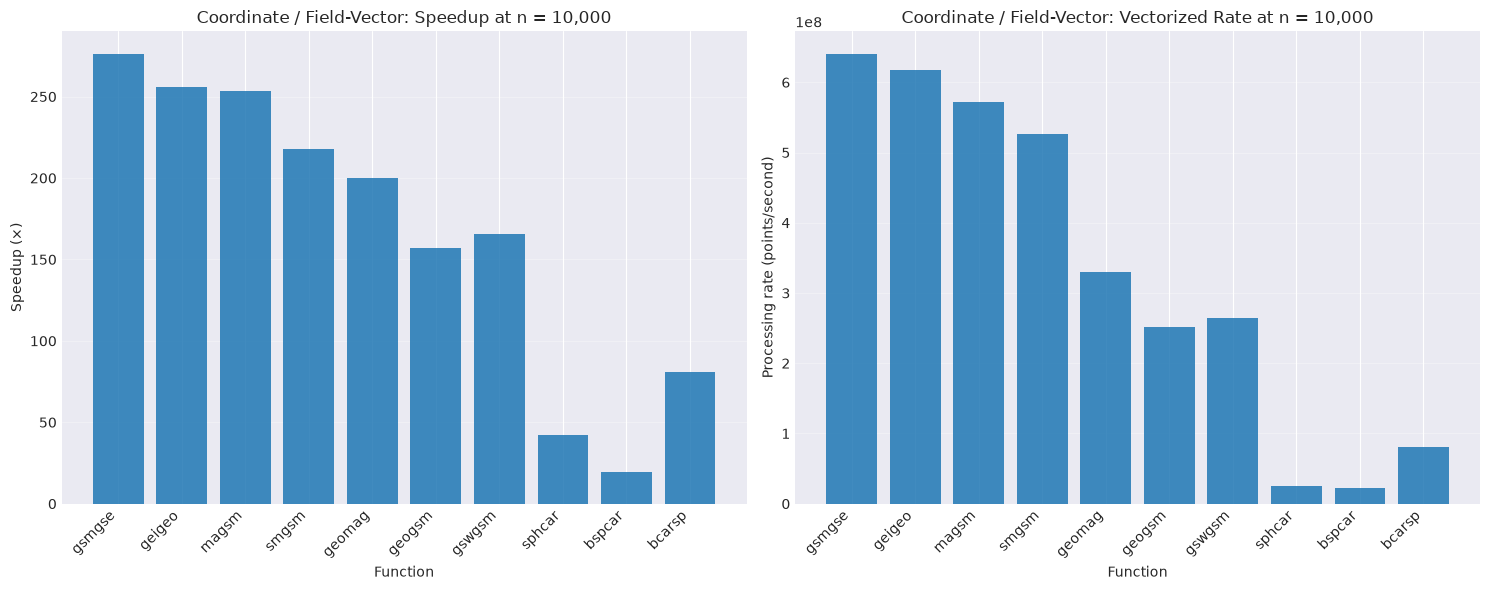

In [4]:
# Plot coordinate speedups and vector rates (n=10,000)
func_names = list(coord_results.keys())
speedups_10k = [coord_results[k][2]["speedup_x"] for k in func_names]
rates_10k = [coord_results[k][2]["vector_rate_pts_s"] for k in func_names]

xpos = np.arange(len(func_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(xpos, speedups_10k, alpha=0.85)
ax1.set_xticks(xpos)
ax1.set_xticklabels(func_names, rotation=45, ha="right")
ax1.set_xlabel("Function")
ax1.set_ylabel("Speedup (×)")
ax1.set_title("Coordinate / Field-Vector: Speedup at n = 10,000")
ax1.grid(True, alpha=0.3, axis="y")

ax2.bar(xpos, rates_10k, alpha=0.85)
ax2.set_xticks(xpos)
ax2.set_xticklabels(func_names, rotation=45, ha="right")
ax2.set_xlabel("Function")
ax2.set_ylabel("Processing rate (points/second)")
ax2.set_title("Coordinate / Field-Vector: Vectorized Rate at n = 10,000")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## 3. Magnetic Field Model Performance <a name="models"></a>


We benchmark the **external** Tsyganenko models:

- T89, T96, T01, T04


Note:

- For T01/T04 we sample **x ∈ [-15, 12] Re** to avoid out-of-domain warnings.

In [5]:
# Model parameters
parmod_default = np.zeros(10, dtype=np.float64)
parmod_default[0] = 3.0    # Pdyn (nPa)
parmod_default[1] = -20.0  # Dst (nT)
parmod_default[2] = 0.0    # ByIMF (nT)
parmod_default[3] = -5.0   # BzIMF (nT)

parmod_t01 = parmod_default.copy()
parmod_t01[4] = 2.0
parmod_t01[5] = 3.0

parmod_t04 = parmod_default.copy()
parmod_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

model_functions = [
    ("T89", geopack.t89, geopack.t89_vectorized, 4),
    ("T96", geopack.t96, geopack.t96_vectorized, parmod_default),
    ("T01", geopack.t01, geopack.t01_vectorized, parmod_t01),
    ("T04", geopack.t04, geopack.t04_vectorized, parmod_t04),
]

model_results = {}
print("\nExternal Field Model Performance (Tsyganenko)")
print("=" * 90)
print(f"{'Model':6s} {'n':>8s} {'scalar(s)':>12s} {'vector(s)':>12s} {'speedup':>9s} {'rate(vec) pts/s':>16s}")

for model_name, f_s, f_v, params in model_functions:
    rows = []
    for n in [100, 1000, 10000]:
        r = measure_performance(
            f_s, f_v, n,
            func_type="model",
            params=params,
            model_name=model_name,
        )
        rows.append(r)
        print(f"{model_name:6s} {n:8d} {r['scalar_time_s']:12.4f} {r['vector_time_s']:12.4f} "
              f"{r['speedup_x']:9.1f}x {r['vector_rate_pts_s']:16.0f}"
              + ("  (scalar extrap)" if r["scalar_extrapolated"] else ""))
    model_results[model_name] = rows



External Field Model Performance (Tsyganenko)
Model         n    scalar(s)    vector(s)   speedup  rate(vec) pts/s
T89         100       0.0024       0.0002      14.6x           621744
T89        1000       0.0244       0.0003      85.2x          3487456
T89       10000       0.2424       0.0045      53.8x          2218124  (scalar extrap)


T96         100       0.0396       0.0141       2.8x             7095


T96        1000       0.4244       0.0240      17.7x            41676


T96       10000       4.1877       0.0864      48.5x           115719  (scalar extrap)


T01         100       0.0752       0.0121       6.2x             8242


T01        1000       0.7975       0.0350      22.8x            28533


T01       10000       8.1315       0.2267      35.9x            44119  (scalar extrap)


T04         100       0.0826       0.0119       6.9x             8373


T04        1000       0.8851       0.0331      26.7x            30182


T04       10000       8.2016       0.2336      35.1x            42816  (scalar extrap)


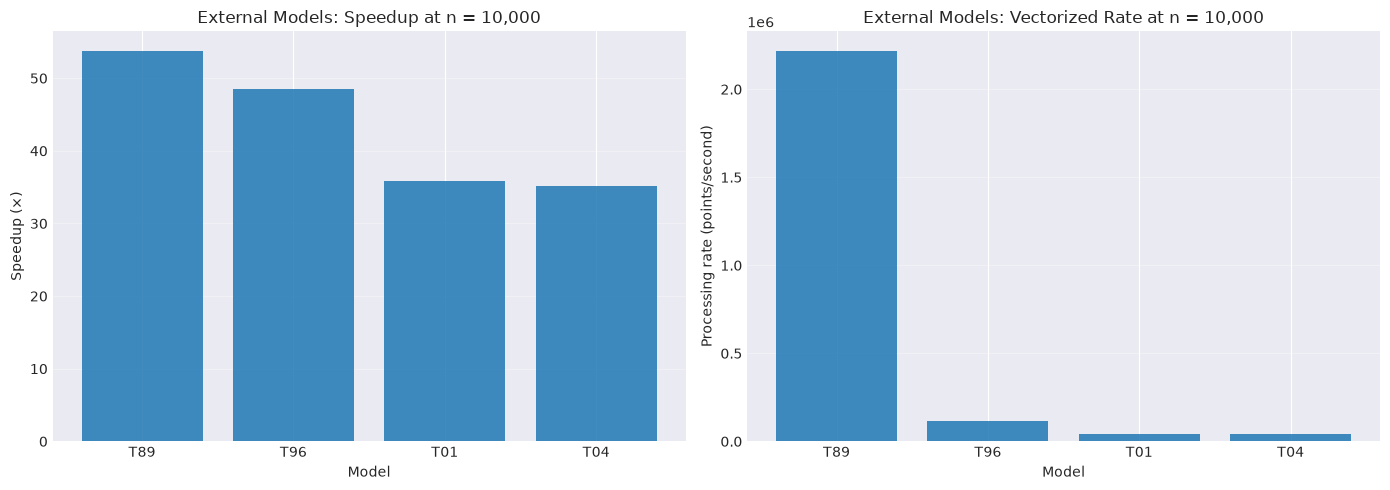

In [6]:
# Plot external model speedups and rates (n=10,000)
model_names = list(model_results.keys())
speedups_10k = [model_results[m][2]["speedup_x"] for m in model_names]
rates_10k = [model_results[m][2]["vector_rate_pts_s"] for m in model_names]

xpos = np.arange(len(model_names))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(xpos, speedups_10k, alpha=0.85)
ax1.set_xticks(xpos)
ax1.set_xticklabels(model_names)
ax1.set_xlabel("Model")
ax1.set_ylabel("Speedup (×)")
ax1.set_title("External Models: Speedup at n = 10,000")
ax1.grid(True, alpha=0.3, axis="y")

ax2.bar(xpos, rates_10k, alpha=0.85)
ax2.set_xticks(xpos)
ax2.set_xticklabels(model_names)
ax2.set_xlabel("Model")
ax2.set_ylabel("Processing rate (points/second)")
ax2.set_title("External Models: Vectorized Rate at n = 10,000")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## 3b. Internal Field Performance (IGRF only)


Dipole (`dip`) is already vectorization-native in geopack (it accepts arrays directly),

so comparing "scalar vs vector" is not meaningful here.


Instead, we benchmark only IGRF:

- `igrf_gsw` vs `igrf_gsw_vectorized` (preferred if available)

- `igrf_gsm` vs `igrf_gsm_vectorized` (fallback / optional)


Notes:

- IGRF is most meaningful near Earth; we sample within roughly ±10 Re.


Internal Field Performance (IGRF only)
Internal          n    scalar(s)    vector(s)   speedup  rate(vec) pts/s
IGRF_GSW        100       0.0035       0.0010       3.6x           102731


IGRF_GSW       1000       0.0380       0.0048       7.9x           209113


IGRF_GSW      10000       0.3791       0.0310      12.2x           322477  (scalar extrap)
IGRF_GSM        100       0.0031       0.0009       3.5x           111575
IGRF_GSM       1000       0.0354       0.0045       7.9x           223670


IGRF_GSM      10000       0.3682       0.0312      11.8x           320546  (scalar extrap)


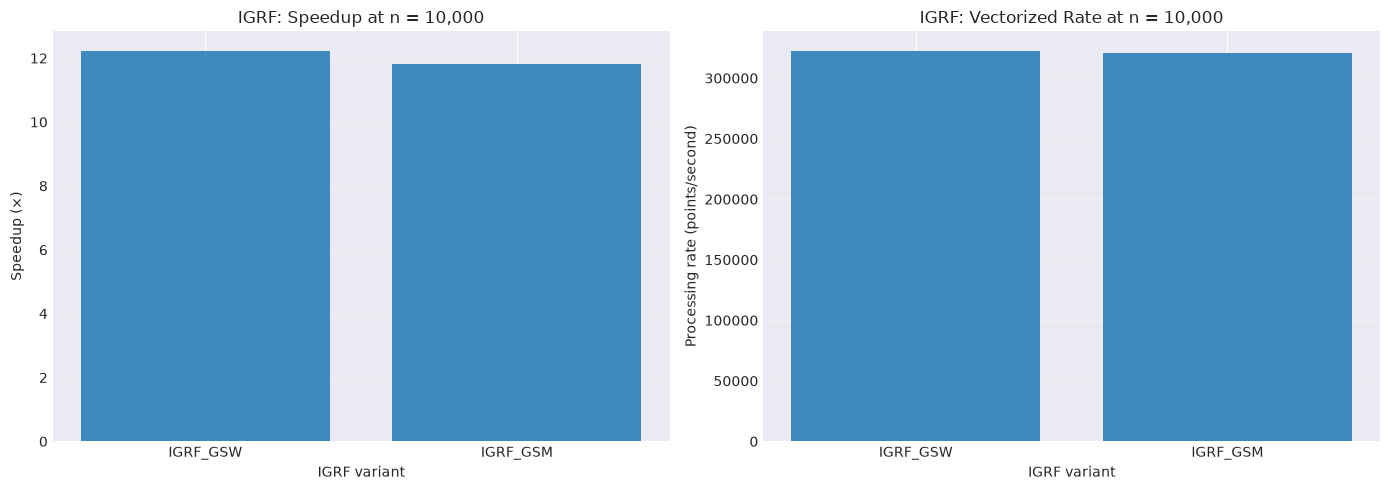

In [7]:
internal_results = {}

print("\nInternal Field Performance (IGRF only)")
print("=" * 90)
print(f"{'Internal':10s} {'n':>8s} {'scalar(s)':>12s} {'vector(s)':>12s} {'speedup':>9s} {'rate(vec) pts/s':>16s}")

# IGRF (GSW)
if hasattr(geopack, "igrf_gsw") and hasattr(geopack, "igrf_gsw_vectorized"):
    internal_results["IGRF_GSW"] = []
    for n in [100, 1000, 10000]:
        r = measure_performance(geopack.igrf_gsw, geopack.igrf_gsw_vectorized, n, func_type="igrf")
        internal_results["IGRF_GSW"].append(r)
        print(f"{'IGRF_GSW':10s} {n:8d} {r['scalar_time_s']:12.4f} {r['vector_time_s']:12.4f} "
              f"{r['speedup_x']:9.1f}x {r['vector_rate_pts_s']:16.0f}"
              + ("  (scalar extrap)" if r["scalar_extrapolated"] else ""))
else:
    print("IGRF_GSW benchmark skipped: geopack.igrf_gsw / igrf_gsw_vectorized not found")

# IGRF (GSM) - optional
if hasattr(geopack, "igrf_gsm") and hasattr(geopack, "igrf_gsm_vectorized"):
    internal_results["IGRF_GSM"] = []
    for n in [100, 1000, 10000]:
        r = measure_performance(geopack.igrf_gsm, geopack.igrf_gsm_vectorized, n, func_type="igrf")
        internal_results["IGRF_GSM"].append(r)
        print(f"{'IGRF_GSM':10s} {n:8d} {r['scalar_time_s']:12.4f} {r['vector_time_s']:12.4f} "
              f"{r['speedup_x']:9.1f}x {r['vector_rate_pts_s']:16.0f}"
              + ("  (scalar extrap)" if r["scalar_extrapolated"] else ""))
else:
    print("IGRF_GSM benchmark skipped: geopack.igrf_gsm / igrf_gsm_vectorized not found")

# Plot internal model speedups (n=10,000) if present
labels, speedups, rates = [], [], []
for k, rows in internal_results.items():
    if len(rows) >= 3:
        labels.append(k)
        speedups.append(rows[2]["speedup_x"])
        rates.append(rows[2]["vector_rate_pts_s"])

if labels:
    xpos = np.arange(len(labels))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(xpos, speedups, alpha=0.85)
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(labels)
    ax1.set_xlabel("IGRF variant")
    ax1.set_ylabel("Speedup (×)")
    ax1.set_title("IGRF: Speedup at n = 10,000")
    ax1.grid(True, alpha=0.3, axis="y")

    ax2.bar(xpos, rates, alpha=0.85)
    ax2.set_xticks(xpos)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel("IGRF variant")
    ax2.set_ylabel("Processing rate (points/second)")
    ax2.set_title("IGRF: Vectorized Rate at n = 10,000")
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()



## 3c. Where Does the Speedup Come From? Call Overhead vs Per-Point Cost <a name="decomposition"></a>

A natural hypothesis for the scalar-vs-vectorized gap is **function-call overhead**: the scalar API requires one Python call per point, so the vectorized version might be faster simply because it makes 1 call instead of N. This section tests that hypothesis directly with two experiments:

1. **Single-point equivalence test.** If the gain came only from the *number of calls*, a vectorized call on a 1-element array should cost about the same as one scalar call. We measure both.

2. **Small-array scaling.** We measure the execution time $t(n)$ for $n = 1, 2, 4, 8, 16, \dots, 1024$ and model the vectorized cost as $t_{\mathrm{vec}}(n) \approx a + b \cdot n$, where $a$ is the fixed per-call overhead and $b$ is the marginal cost per point. Comparing $b$ with the scalar per-point cost separates the "fewer calls" effect from a genuine per-point throughput effect (compiled NumPy loops, possibly using SIMD).

Methodology notes:

- Every timing cycles through several **distinct** input chunks. Timing a single fixed point repeatedly is unreliable, because one point can hit an unusually cheap or expensive branch of a model.

- Repetition counts are auto-calibrated so that each timing window is long enough for the clock resolution, and the best of several repeats is taken (same policy as Section 1).


In [8]:
# Small-array benchmark: separate the fixed per-call overhead from the per-point cost.
# Runtime: ~1 minute (dominated by the scalar loops of the T96/T01/T04 models).

SMALL_NS = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
_DECOMP_POOL = max(SMALL_NS)

def _timed_over_chunks(call_one_chunk, chunks, n_repeats=3, min_window=0.02):
    """Best-of-repeats mean time of call_one_chunk(chunk), cycling over several
    *distinct* data chunks. Timing one fixed point repeatedly is unreliable:
    a single point can hit an unusually cheap or expensive branch of a model."""
    call_one_chunk(chunks[0])  # warmup
    t0 = _now()
    for c in chunks:
        call_one_chunk(c)
    t_pass = _now() - t0
    n_pass = max(1, int(np.ceil(min_window / max(t_pass, 1e-9))))
    best = np.inf
    for _ in range(n_repeats):
        t0 = _now()
        for _ in range(n_pass):
            for c in chunks:
                call_one_chunk(c)
        best = min(best, (_now() - t0) / (n_pass * len(chunks)))
    return float(best)

def measure_small_n(scalar_call, vector_call, xlim, ylim, zlim, sizes=SMALL_NS):
    """Time scalar loops and single vectorized calls over small array sizes."""
    x, y, z = sample_xyz(_DECOMP_POOL, xlim, ylim, zlim)
    rows = []
    for n in sizes:
        n_chunk_s = max(1, min(8, 512 // n))  # cap total scalar calls per pass
        n_chunk_v = max(1, min(8, _DECOMP_POOL // n))
        chunks_s = [(x[i*n:(i+1)*n], y[i*n:(i+1)*n], z[i*n:(i+1)*n]) for i in range(n_chunk_s)]
        chunks_v = [(x[i*n:(i+1)*n], y[i*n:(i+1)*n], z[i*n:(i+1)*n]) for i in range(n_chunk_v)]

        def scalar_loop(chunk):
            cx, cy, cz = chunk
            for i in range(len(cx)):
                scalar_call(float(cx[i]), float(cy[i]), float(cz[i]))

        def vector_once(chunk):
            vector_call(chunk[0], chunk[1], chunk[2])

        rows.append({
            "n": n,
            "scalar_s": _timed_over_chunks(scalar_loop, chunks_s),
            "vector_s": _timed_over_chunks(vector_once, chunks_v),
        })
    return rows

def decompose_costs(rows):
    """Fit t(n) ~ a + b*n: slopes from n >= 128, overhead from n <= 16 residuals."""
    n = np.array([r["n"] for r in rows], dtype=float)
    ts = np.array([r["scalar_s"] for r in rows])
    tv = np.array([r["vector_s"] for r in rows])
    big = n >= 128
    b_s = np.polyfit(n[big], ts[big], 1)[0]
    b_v = np.polyfit(n[big], tv[big], 1)[0]
    a_v = float(np.median((tv - b_v * n)[n <= 16]))
    ratio = ts / tv
    if np.all(ratio >= 1.0):
        n_cross = 1.0
    elif np.all(ratio < 1.0):
        n_cross = np.inf
    else:  # log-interpolate the first upward crossing of speedup = 1
        hi = int(np.argmax(ratio >= 1.0))
        lo = hi - 1
        f = -np.log(ratio[lo]) / (np.log(ratio[hi]) - np.log(ratio[lo]))
        n_cross = float(np.exp(np.log(n[lo]) + f * (np.log(n[hi]) - np.log(n[lo]))))
    return {"b_scalar": float(b_s), "b_vector": float(b_v), "a_vector": a_v,
            "slope_ratio": float(b_s / b_v), "n_cross": n_cross}

def _decomp_target(name, f_s, f_v, params, xlim, ylim=(-15, 15), zlim=(-15, 15)):
    if params is None:  # IGRF-style signature (x, y, z)
        return (name, f_s, f_v, xlim, ylim, zlim)
    return (name,
            lambda x_, y_, z_: f_s(params, ps, x_, y_, z_),
            lambda x_, y_, z_: f_v(params, ps, x_, y_, z_),
            xlim, ylim, zlim)

decomp_targets = [
    _decomp_target("T89", geopack.t89, geopack.t89_vectorized, 4, (-25.0, 12.0)),
    _decomp_target("T96", geopack.t96, geopack.t96_vectorized, parmod_default, (-25.0, 12.0)),
    _decomp_target("T01", geopack.t01, geopack.t01_vectorized, parmod_t01, (-15.0, 12.0)),
    _decomp_target("T04", geopack.t04, geopack.t04_vectorized, parmod_t04, (-15.0, 12.0)),
]
if hasattr(geopack, "igrf_gsw") and hasattr(geopack, "igrf_gsw_vectorized"):
    decomp_targets.append(_decomp_target("IGRF", geopack.igrf_gsw, geopack.igrf_gsw_vectorized,
                                         None, (-10.0, 10.0), (-10.0, 10.0), (-10.0, 10.0)))

decomp_results = {}
for name, s_call, v_call, xlim, ylim, zlim in decomp_targets:
    rows = measure_small_n(s_call, v_call, xlim, ylim, zlim)
    decomp_results[name] = {"rows": rows, **decompose_costs(rows)}
    print(f"{name}: measured n = {SMALL_NS}")

summary_rows = []
for name, d in decomp_results.items():
    r = d["rows"]
    summary_rows.append({
        "Component": name,
        "scalar t(1) [µs]": r[0]["scalar_s"] * 1e6,
        "vector t(n=1) [µs]": r[0]["vector_s"] * 1e6,
        "vec(1)/scalar(1)": r[0]["vector_s"] / r[0]["scalar_s"],
        "vec overhead a [µs/call]": d["a_vector"] * 1e6,
        "vec marginal b [µs/pt]": d["b_vector"] * 1e6,
        "scalar per-point [µs/pt]": d["b_scalar"] * 1e6,
        "per-point ratio b_s/b_v": d["slope_ratio"],
        "break-even n*": d["n_cross"],
    })
df_decomp = pd.DataFrame(summary_rows).round(2)
display(df_decomp)

# Finite-difference marginal-cost estimates at small n (cf. overhead estimation
# from t(1) and t(2), and the n = 4, 8, 16 comparison):
print("Vectorized call: finite-difference marginal costs at small n (µs/point)")
print(f"{'Component':10s} {'t(2)-t(1)':>12s} {'[t(4)-t(2)]/2':>14s} {'[t(8)-t(4)]/4':>14s} {'[t(16)-t(8)]/8':>15s}")
for name, d in decomp_results.items():
    t = {r["n"]: r["vector_s"] for r in d["rows"]}
    print(f"{name:10s} {(t[2]-t[1])*1e6:12.2f} {(t[4]-t[2])/2*1e6:14.2f} "
          f"{(t[8]-t[4])/4*1e6:14.2f} {(t[16]-t[8])/8*1e6:15.2f}")
print("\nNote: t_vec(n) is not strictly linear at very small n, so these finite")
print("differences are noisy; the fitted slope b (table above) is the robust estimate.")


T89: measured n = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]


T96: measured n = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]


T01: measured n = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]


T04: measured n = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]


IGRF: measured n = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]


,Component,scalar t(1) [µs],vector t(n=1) [µs],vec(1)/scalar(1),vec overhead a [µs/call],vec marginal b [µs/pt],scalar per-point [µs/pt],per-point ratio b_s/b_v,break-even n*
0,T89,27.93,194.57,6.97,182.85,0.11,26.86,244.11,7.26
1,T96,334.81,3096.55,9.25,7980.69,6.84,499.42,73.03,29.19
2,T01,635.33,11116.58,17.50,10948.49,22.90,826.53,36.09,14.02
3,T04,608.08,11475.05,18.87,11351.96,19.72,800.26,40.58,13.50
4,IGRF,31.81,517.72,16.27,794.79,2.84,31.61,11.13,46.57


Vectorized call: finite-difference marginal costs at small n (µs/point)
Component     t(2)-t(1)  [t(4)-t(2)]/2  [t(8)-t(4)]/4  [t(16)-t(8)]/8
T89              -34.73          11.73          -2.80            2.03
T96             2648.41        1131.55         636.85          148.30
T01             -346.67          13.39          83.75          122.04
T04              795.94        -477.49          48.43          -36.20
IGRF             178.39          55.02          21.16           35.23

Note: t_vec(n) is not strictly linear at very small n, so these finite
differences are noisy; the fitted slope b (table above) is the robust estimate.


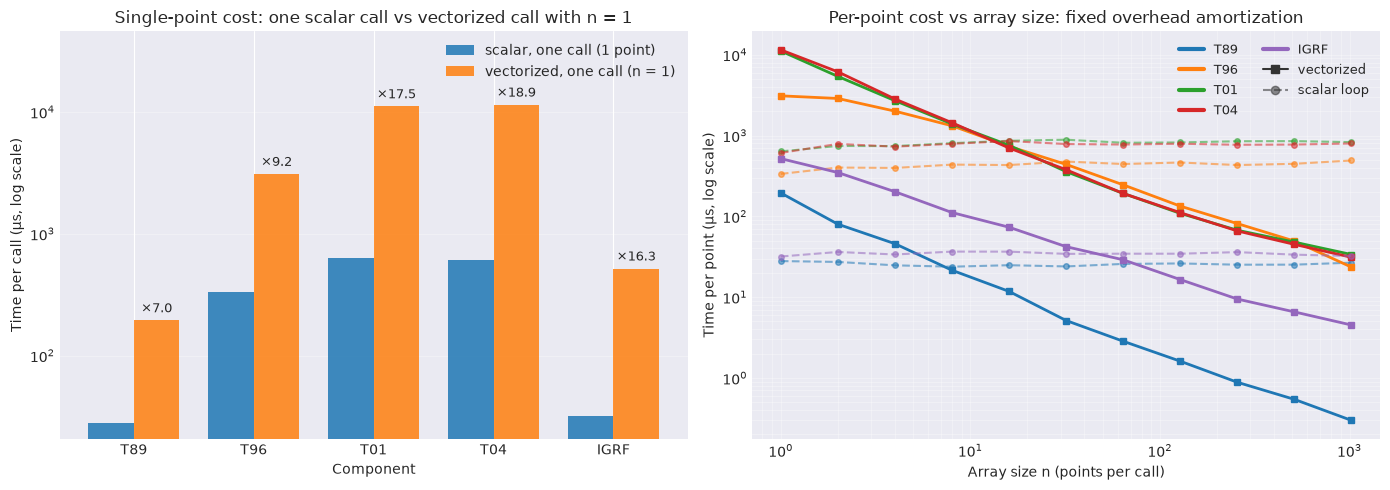

In [9]:
# Figure: single-point equivalence test and per-point cost amortization
from matplotlib.lines import Line2D

decomp_comps = list(decomp_results.keys())
decomp_colors = {c: f"C{i}" for i, c in enumerate(decomp_comps)}  # fixed color per component

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (a) one scalar call vs one vectorized call with n = 1
xpos = np.arange(len(decomp_comps))
w = 0.38
t_s1 = np.array([decomp_results[c]["rows"][0]["scalar_s"] for c in decomp_comps]) * 1e6
t_v1 = np.array([decomp_results[c]["rows"][0]["vector_s"] for c in decomp_comps]) * 1e6
ax1.bar(xpos - w/2, t_s1, w, alpha=0.85, label="scalar, one call (1 point)")
ax1.bar(xpos + w/2, t_v1, w, alpha=0.85, label="vectorized, one call (n = 1)")
for i in range(len(decomp_comps)):
    ax1.annotate(f"×{t_v1[i]/t_s1[i]:.1f}", (xpos[i] + w/2, t_v1[i] * 1.1),
                 ha="center", va="bottom", fontsize=9)
ax1.set_yscale("log")
ax1.set_xticks(xpos)
ax1.set_xticklabels(decomp_comps)
ax1.set_xlabel("Component")
ax1.set_ylabel("Time per call (µs, log scale)")
ax1.set_title("Single-point cost: one scalar call vs vectorized call with n = 1")
ax1.set_ylim(top=max(t_v1) * 4)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# (b) time per point vs array size: overhead amortization
for c in decomp_comps:
    rows = decomp_results[c]["rows"]
    n = np.array([r["n"] for r in rows], dtype=float)
    ts = np.array([r["scalar_s"] for r in rows]) / n * 1e6
    tv = np.array([r["vector_s"] for r in rows]) / n * 1e6
    col = decomp_colors[c]
    ax2.loglog(n, tv, "s-", color=col, linewidth=2, markersize=5)
    ax2.loglog(n, ts, "o--", color=col, linewidth=1.5, markersize=4, alpha=0.55)
comp_handles = [Line2D([0], [0], color=decomp_colors[c], linewidth=3, label=c)
                for c in decomp_comps]
style_handles = [
    Line2D([0], [0], color="0.2", ls="-", marker="s", label="vectorized"),
    Line2D([0], [0], color="0.2", ls="--", marker="o", alpha=0.55, label="scalar loop"),
]
ax2.legend(handles=comp_handles + style_handles, ncol=2, fontsize=9)
ax2.set_xlabel("Array size n (points per call)")
ax2.set_ylabel("Time per point (µs, log scale)")
ax2.set_title("Per-point cost vs array size: fixed overhead amortization")
ax2.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


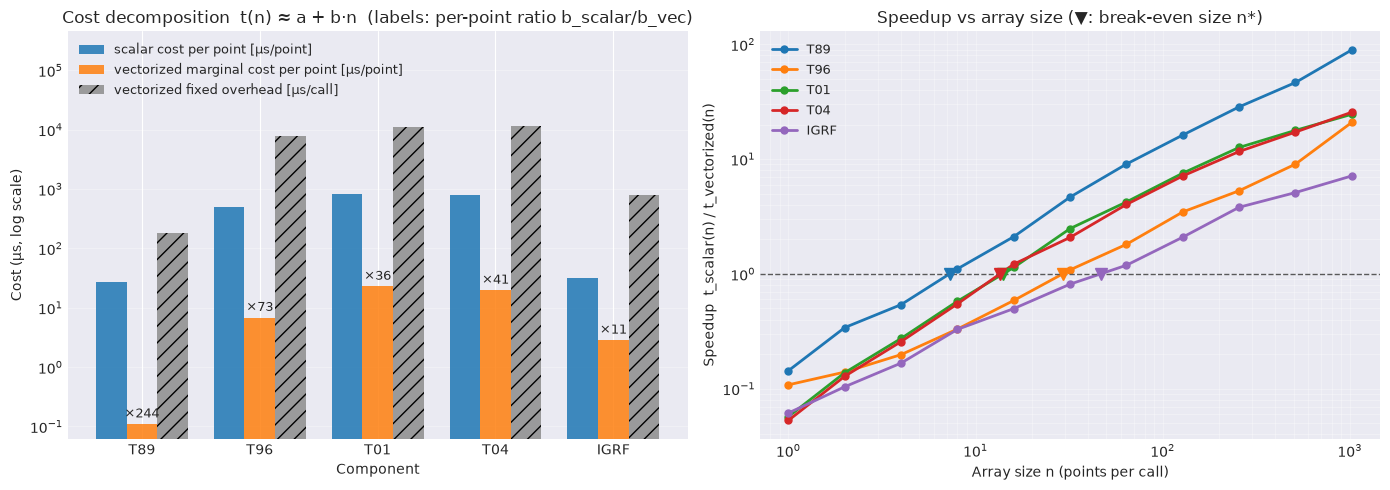

In [10]:
# Figure: cost decomposition t(n) ~ a + b*n and break-even array size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (a) decomposition: scalar per-point cost vs vectorized marginal cost and overhead
xpos = np.arange(len(decomp_comps))
w = 0.26
b_s = np.array([decomp_results[c]["b_scalar"] for c in decomp_comps]) * 1e6
b_v = np.array([decomp_results[c]["b_vector"] for c in decomp_comps]) * 1e6
a_v = np.array([decomp_results[c]["a_vector"] for c in decomp_comps]) * 1e6
ax1.bar(xpos - w, b_s, w, alpha=0.85, label="scalar cost per point [µs/point]")
ax1.bar(xpos, b_v, w, alpha=0.85, label="vectorized marginal cost per point [µs/point]")
ax1.bar(xpos + w, a_v, w, alpha=0.85, color="0.55", hatch="//",
        label="vectorized fixed overhead [µs/call]")
for i in range(len(decomp_comps)):
    ax1.annotate(f"×{b_s[i]/b_v[i]:.0f}", (xpos[i], b_v[i] * 1.15),
                 ha="center", va="bottom", fontsize=9)
ax1.set_yscale("log")
ax1.set_xticks(xpos)
ax1.set_xticklabels(decomp_comps)
ax1.set_xlabel("Component")
ax1.set_ylabel("Cost (µs, log scale)")
ax1.set_title("Cost decomposition  t(n) ≈ a + b·n  (labels: per-point ratio b_scalar/b_vec)")
ax1.set_ylim(top=max(a_v.max(), b_s.max()) * 40)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, alpha=0.3, axis="y")

# (b) speedup vs array size with break-even markers
for c in decomp_comps:
    rows = decomp_results[c]["rows"]
    n = np.array([r["n"] for r in rows], dtype=float)
    sp = np.array([r["scalar_s"] / r["vector_s"] for r in rows])
    col = decomp_colors[c]
    ax2.loglog(n, sp, "o-", color=col, linewidth=2, markersize=5, label=c)
    nc = decomp_results[c]["n_cross"]
    if np.isfinite(nc):
        ax2.plot([nc], [1.0], marker="v", color=col, markersize=9, zorder=5)
ax2.axhline(1.0, color="0.35", linestyle="--", linewidth=1)
ax2.set_xlabel("Array size n (points per call)")
ax2.set_ylabel("Speedup  t_scalar(n) / t_vectorized(n)")
ax2.set_title("Speedup vs array size (▼: break-even size n*)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


### Interpretation

**1. A vectorized call with n = 1 is *not* equivalent to a scalar call.** On the test machine it is roughly 7–20× *slower* (left panel of the first figure). The vectorized implementations pay a fixed overhead $a$ on every call: NumPy per-operation dispatch, temporary-array allocation, broadcasting, and the evaluation of both branches of every `np.where` (the scalar code takes only one side of each `if`/`else`). For a single point, each of these array operations costs far more than the corresponding scalar float operation.

**2. The fixed overhead tracks model complexity, not a constant call cost.** A Python function call itself costs on the order of 1 µs, yet the measured overhead ranges from ~0.15 ms (T89) to ~7–10 ms (T96/T01/T04). The overhead is the accumulated per-array-operation cost of the model body — complex models execute more NumPy operations, so their fixed overhead is larger. The speedup therefore cannot be explained as "the same computation minus (N − 1) function calls".

**3. The per-point cost itself drops far more than SIMD alone could deliver.** The fitted marginal cost per point of the vectorized call is one to two orders of magnitude smaller than the scalar per-point cost (left panel of the second figure; ≈10× for IGRF and ≈35–250× for the Tsyganenko models — the exact ratio for the very fast T89 model is sensitive to timing noise, but it stays far above the SIMD width in every run). SIMD on float64 provides at most 4 lanes (AVX2) or 8 lanes (AVX-512), so SIMD cannot account for this magnitude. The dominant mechanism is that the scalar version executes every arithmetic operation through the Python interpreter (bytecode dispatch, float boxing) once *per point*, whereas the vectorized version executes each operation once *per array* inside compiled C loops — the interpreter overhead is amortized over all elements. SIMD and cache effects inside NumPy's kernels contribute on top of that, but they are not the primary factor.

**4. Break-even array size.** The speedup crosses 1 at roughly n\* ≈ 7–50 points depending on the model (right panel of the second figure, ▼ markers). Below n\*, the fixed overhead dominates and scalar calls are faster — consistent with the recommendations in Section 6. Beyond n\*, the overhead amortizes and the speedup approaches the per-point ratio $b_{\mathrm{scalar}}/b_{\mathrm{vec}}$.

**Summary.** The observed speedup is *not* primarily a function-call-count effect. It comes from replacing per-point interpreted execution with per-array compiled execution, at the price of a fixed per-call overhead that makes the vectorized functions *slower* than scalar calls for very small arrays.


## 4. Scaling Analysis <a name="scaling"></a>


We run a more detailed scaling sweep for a representative coordinate transform and a representative model.

In [11]:
scaling_functions = [
    ("gsmgse", geopack.gsmgse, geopack.gsmgse_vectorized, "coord", dict(direction=1)),
    ("T96", geopack.t96, geopack.t96_vectorized, "model", dict(params=parmod_default, model_name="T96")),
]

scaling_results = {}
print("\nScaling analysis")
print("=" * 60)

for func_name, f_s, f_v, ftype, kwargs in scaling_functions:
    res = []
    print(f"\n{func_name}")
    for n in test_sizes:
        r = measure_performance(f_s, f_v, n, func_type=ftype, **kwargs)
        res.append(r)
        if n <= 10000:
            print(f"  n={n:6d}: speedup={r['speedup_x']:7.2f}x  vector={r['vector_time_s']:.4e}s")
    scaling_results[func_name] = res



Scaling analysis

gsmgse
  n=     1: speedup=   0.20x  vector=3.7471e-06s
  n=    10: speedup=   1.33x  vector=3.6489e-06s
  n=    50: speedup=   5.66x  vector=3.5900e-06s
  n=   100: speedup=  11.81x  vector=3.4031e-06s
  n=   500: speedup=  51.49x  vector=3.9381e-06s
  n=  1000: speedup=  34.44x  vector=1.1789e-05s
  n=  5000: speedup=  71.50x  vector=2.8953e-05s
  n= 10000: speedup= 254.33x  vector=1.6837e-05s

T96
  n=     1: speedup=   0.11x  vector=5.2984e-03s
  n=    10: speedup=   0.60x  vector=4.9636e-03s
  n=    50: speedup=   1.87x  vector=1.1431e-02s


  n=   100: speedup=   2.77x  vector=1.4449e-02s


  n=   500: speedup=   9.97x  vector=1.9984e-02s


  n=  1000: speedup=  16.96x  vector=2.3715e-02s


  n=  5000: speedup=  38.92x  vector=5.1847e-02s


  n= 10000: speedup=  50.30x  vector=7.9999e-02s


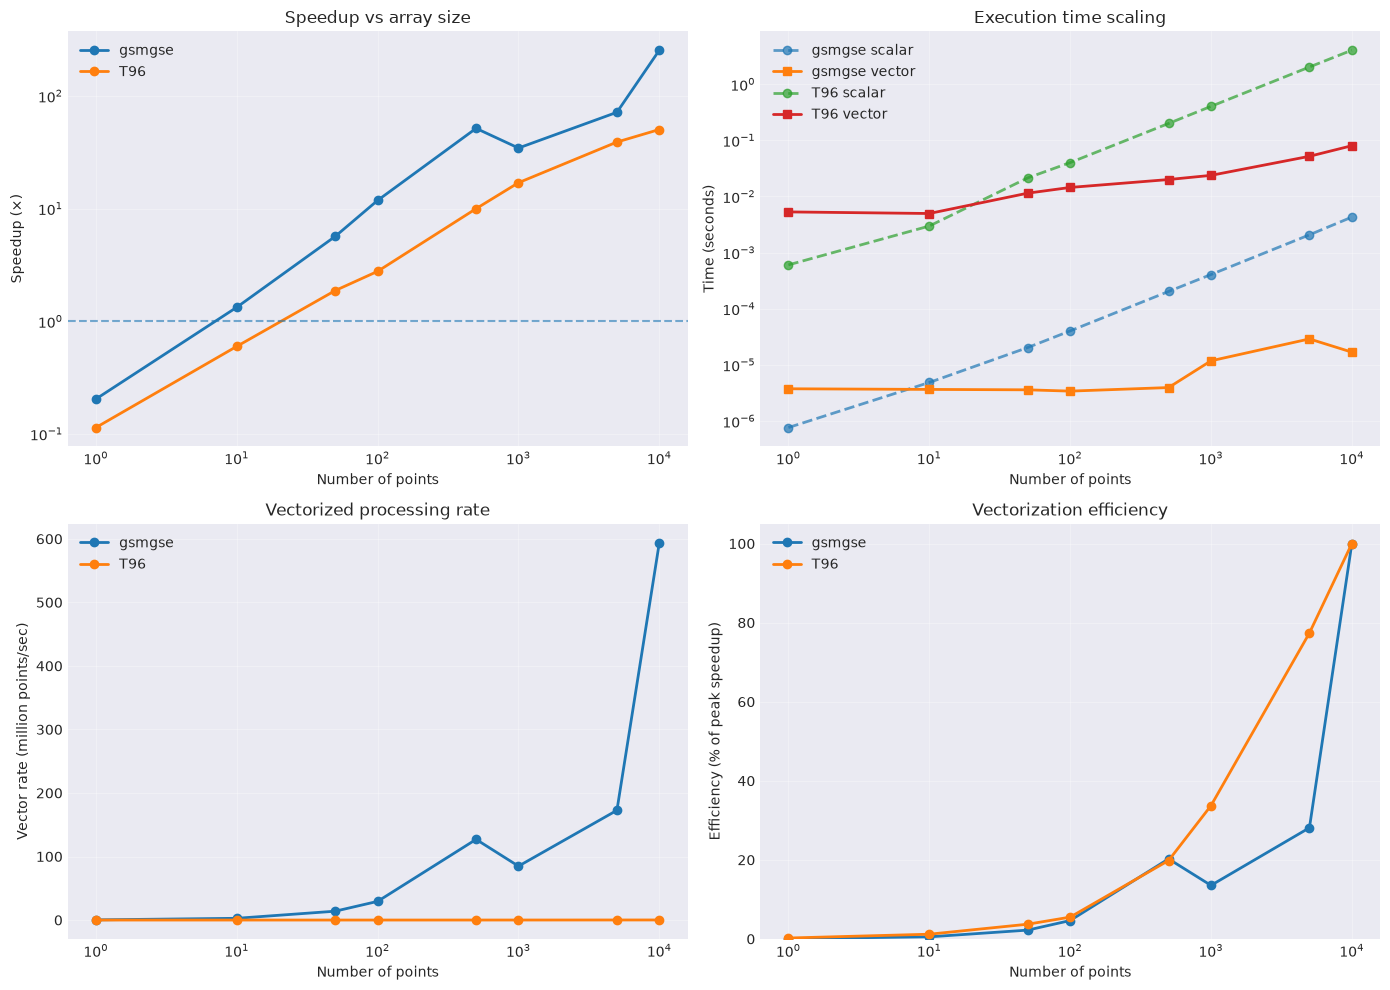

In [12]:
# Plot scaling curves
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Speedup vs size
for func_name, res in scaling_results.items():
    sizes = [r["n_points"] for r in res]
    speedups = [r["speedup_x"] for r in res]
    ax1.loglog(sizes, speedups, "o-", linewidth=2, label=func_name)
ax1.set_xlabel("Number of points")
ax1.set_ylabel("Speedup (×)")
ax1.set_title("Speedup vs array size")
ax1.grid(True, alpha=0.3)
ax1.axhline(1.0, linestyle="--", alpha=0.6)
ax1.legend()

# Time scaling
for func_name, res in scaling_results.items():
    sizes = [r["n_points"] for r in res]
    t_s = [r["scalar_time_s"] for r in res]
    t_v = [r["vector_time_s"] for r in res]
    ax2.loglog(sizes, t_s, "o--", linewidth=2, alpha=0.7, label=f"{func_name} scalar")
    ax2.loglog(sizes, t_v, "s-", linewidth=2, label=f"{func_name} vector")
ax2.set_xlabel("Number of points")
ax2.set_ylabel("Time (seconds)")
ax2.set_title("Execution time scaling")
ax2.grid(True, alpha=0.3)
ax2.legend()

# Vector rate
for func_name, res in scaling_results.items():
    sizes = [r["n_points"] for r in res]
    rates = [r["vector_rate_pts_s"] for r in res]
    ax3.semilogx(sizes, np.array(rates) / 1e6, "o-", linewidth=2, label=func_name)
ax3.set_xlabel("Number of points")
ax3.set_ylabel("Vector rate (million points/sec)")
ax3.set_title("Vectorized processing rate")
ax3.grid(True, alpha=0.3)
ax3.legend()

# Efficiency
for func_name, res in scaling_results.items():
    sizes = [r["n_points"] for r in res]
    speedups = np.array([r["speedup_x"] for r in res])
    eff = 100.0 * speedups / max(speedups.max(), 1e-15)
    ax4.semilogx(sizes, eff, "o-", linewidth=2, label=func_name)
ax4.set_xlabel("Number of points")
ax4.set_ylabel("Efficiency (% of peak speedup)")
ax4.set_title("Vectorization efficiency")
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 105)
ax4.legend()

plt.tight_layout()
plt.show()


## 5. Memory Efficiency <a name="memory"></a>


This section provides a rough RSS-based memory estimate (best-effort).

Memory numbers can be noisy; use for sanity-checking rather than exact accounting.

In [13]:
def measure_memory_usage_vector_call(call_fn, n_points, seed=SEED):
    """
    Measure memory (RSS) before and after one vectorized call.
    Requires psutil.
    """
    if not _HAS_PSUTIL:
        raise RuntimeError("psutil not available")

    process = psutil.Process(os.getpid())
    gc.collect()

    baseline = process.memory_info().rss / 1e6  # MB

    # Generate inputs (xyz only; call_fn closes over params as needed)
    x, y, z = sample_xyz(n_points, (-15, 15), (-15, 15), (-15, 15), seed=seed)
    after_data = process.memory_info().rss / 1e6  # MB

    _ = call_fn(x, y, z)
    after_call = process.memory_info().rss / 1e6  # MB

    # Cleanup
    del x, y, z, _
    gc.collect()
    after_cleanup = process.memory_info().rss / 1e6  # MB

    return {
        "baseline_MB": baseline,
        "inputs_MB": max(after_data - baseline, 0.0),
        "call_overhead_MB": max(after_call - after_data, 0.0),
        "total_peak_MB": max(after_call - baseline, 0.0),
        "post_cleanup_MB": after_cleanup,
    }

memory_sizes = [1000, 10000, 100000]  # keep moderate
memory_rows = []

if _HAS_PSUTIL:
    print("\nMemory usage (RSS, best-effort)")
    print("=" * 80)
    print(f"{'N':>10s} {'inputs(MB)':>12s} {'overhead(MB)':>14s} {'peak(MB)':>10s}")

    # Example: T96 vector call
    def _call_t96(x, y, z):
        return geopack.t96_vectorized(parmod_default, ps, x, y, z)

    for n in memory_sizes:
        try:
            mem = measure_memory_usage_vector_call(_call_t96, n)
            memory_rows.append({"component": "T96_vector", "n_points": n, **mem})
            print(f"{n:10d} {mem['inputs_MB']:12.1f} {mem['call_overhead_MB']:14.1f} {mem['total_peak_MB']:10.1f}")
        except MemoryError:
            print(f"{n:10d} MemoryError")
            break

    # Optional: IGRF memory
    if hasattr(geopack, "igrf_gsw_vectorized"):
        def _call_igrf(x, y, z):
            return geopack.igrf_gsw_vectorized(x, y, z)

        for n in memory_sizes:
            try:
                mem = measure_memory_usage_vector_call(_call_igrf, n, seed=SEED+1)
                memory_rows.append({"component": "IGRF_GSW_vector", "n_points": n, **mem})
            except Exception:
                break

    if memory_rows:
        df_mem = pd.DataFrame(memory_rows)
        display(df_mem)
else:
    print("\nMemory section skipped (psutil not available).")



Memory usage (RSS, best-effort)
         N   inputs(MB)   overhead(MB)   peak(MB)
      1000          0.0            0.0        0.0


     10000          0.0            0.0        0.0


    100000          0.0           11.3       11.3


,component,n_points,baseline_MB,inputs_MB,call_overhead_MB,total_peak_MB,post_cleanup_MB
0,T96_vector,1000,197.718016,0.0,0.000000,0.000000,197.718016
1,T96_vector,10000,197.718016,0.0,0.000000,0.000000,197.718016
2,T96_vector,100000,197.718016,0.0,11.341824,11.341824,197.058560
3,IGRF_GSW_vector,1000,197.058560,0.0,0.000000,0.000000,197.058560
4,IGRF_GSW_vector,10000,197.058560,0.0,0.000000,0.000000,197.058560
5,IGRF_GSW_vector,100000,197.058560,0.0,2.400256,2.400256,199.458816


## 6. Best Practices <a name="practices"></a>

In [14]:
recommendations = pd.DataFrame([
    {"Array Size": "1–10 points",    "Recommendation": "Scalar is fine",           "Reason": "Vector overhead often dominates"},
    {"Array Size": "10–100 points",  "Recommendation": "Depends",                  "Reason": "Vector can win if repeated many times"},
    {"Array Size": "100–1,000",      "Recommendation": "Prefer vectorized",        "Reason": "Clear speedup with low overhead"},
    {"Array Size": "1,000+",         "Recommendation": "Always vectorized",        "Reason": "Best throughput; use chunking if needed"},
    {"Array Size": "Very large (≥1e6)", "Recommendation": "Chunking recommended",  "Reason": "Avoid large temporary allocations / RAM pressure"},
])
print("\nPerformance Recommendations")
print("=" * 80)
print(recommendations.to_string(index=False))



Performance Recommendations
       Array Size       Recommendation                                           Reason
      1–10 points       Scalar is fine                  Vector overhead often dominates
    10–100 points              Depends            Vector can win if repeated many times
        100–1,000    Prefer vectorized                  Clear speedup with low overhead
           1,000+    Always vectorized          Best throughput; use chunking if needed
Very large (≥1e6) Chunking recommended Avoid large temporary allocations / RAM pressure
